# Assignment 3: Linear Models

## Dishitha Dhakshin (qxk8wp)

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
A linear model is one where coefficients multiply variables and are added together. “Linear” refers to the parameters, not the inputs, so variables can be transformed (like $x^2$ or $log(x)$) as long as the model stays linear in the coefficients.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

The coefficient for a dummy variable represents the difference in the predicted outcome relative to the baseline (omitted) category, holding other variables constant. The intercept captures the baseline group’s value, and the dummy’s coefficient shows how much the outcome changes when the variable equals 1 instead of 0.

3. Can linear regression be used for classification? Explain why, or why not.

Linear regression can be used for classification by applying a threshold (e.g., predicting class 1 if the output is above 0.5), but it is not ideal. This is because predictions are not constrained between 0 and 1 and can lead to poor probability estimates. Models like logistic regression are preferred since they produce valid probabilities and better fit classification tasks.

4. What are signs that your linear model is over-fitting?

A key sign of overfitting is when the model performs very well on training data but poorly on validation or test data. You may also see overly complex models with large or unstable coefficients that capture noise rather than true patterns.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity occurs when predictors are highly correlated, making it hard to estimate their individual effects. In two-stage least squares (2SLS), you first regress the problematic variable on instruments (variables correlated with it but not with the error) to get predicted values. Then, you use these predicted values in the main regression, which removes the collinearity and yields more stable estimates.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can incorporate nonlinear relationships by transforming the input variables, such as adding polynomial terms (e.g., $x^2$), logarithms, or interaction terms. These transformed features are then included in the model, allowing it to capture nonlinear patterns while remaining linear in the coefficients.

7. What is the interpretation of the slope coefficient in a linear regression?

The slope coefficient represents the expected change in the predicted outcome for a one-unit increase in the corresponding independent variable, holding all other variables constant. It indicates both the direction and magnitude of the relationship between that variable and the response.

8. Compare the train/test split and $k$-fold cross validation.

Train/test split divides the data into one training set and one test set, providing a single estimate of model performance. In contrast, k-fold cross validation splits the data into k subsets and repeatedly trains and tests the model on different folds, giving a more reliable and less variable estimate of performance.


9. How is the $k$ in $k$-fold cross validation typically selected?

The value of $k$ is typically chosen based on a tradeoff between bias and variance. Common choices are $k = 5$ or $k = 10$, which provide a good balance between reliable performance estimates and computational efficiency.

In [1]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 79 (delta 29), reused 13 (delta 13), pack-reused 39 (from 2)
Receiving objects: 100% (79/79), 11.71 MiB | 15.61 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Load data
df = pd.read_csv("./undergrad_ml_assignments/data/Q1_clean.csv")

# Optional: rename columns to make formulas easier
df = df.rename(columns={
    "Review Scores Rating": "Review_Scores_Rating",
    "Neighbourhood ": "Neighbourhood"   # use this if your column has a trailing space
})

print(df.columns)
df.head()

Index(['Price', 'Review_Scores_Rating', 'Neighbourhood', 'Property Type',
       'Room Type'],
      dtype='object')


,Price,Review_Scores_Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.

                    Price  Review_Scores_Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378
Most expensive borough: Manhattan


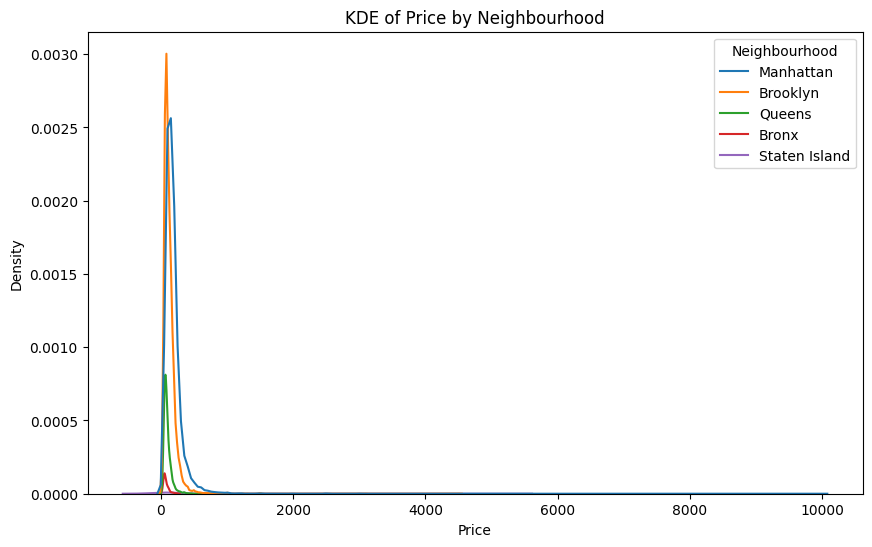

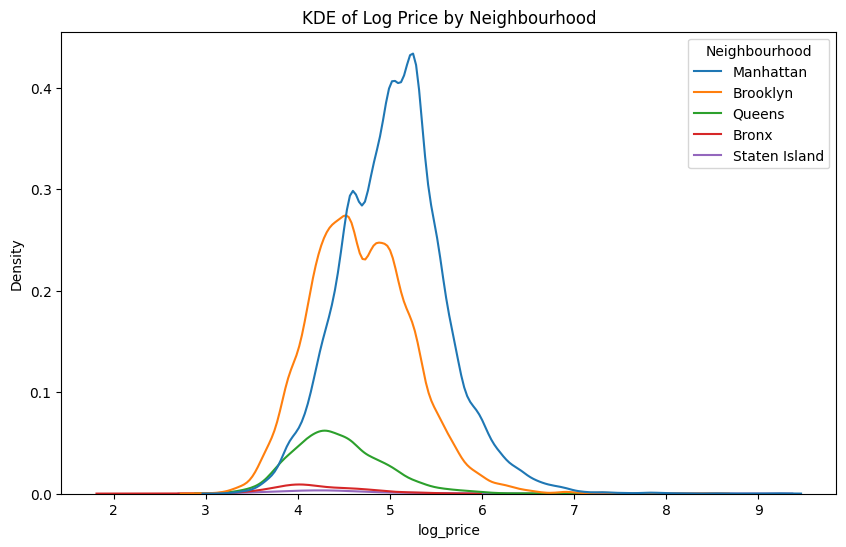

In [11]:
# Compute averages
group_means = df.groupby("Neighbourhood")[["Price", "Review_Scores_Rating"]].mean().sort_values("Price", ascending=False)
print(group_means)

# Most expensive borough
most_expensive = group_means["Price"].idxmax()
print("Most expensive borough:", most_expensive)

# Log price
df["log_price"] = np.log(df["Price"])

# KDE plot for Price
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x="Price", hue="Neighbourhood")
plt.title("KDE of Price by Neighbourhood")
plt.show()

# KDE plot for Log Price
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x="log_price", hue="Neighbourhood")
plt.title("KDE of Log Price by Neighbourhood")
plt.show()

Manhattan is the most expensive borough on average.

2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

In [14]:
# Regression with intercept (drops one category automatically)
model = smf.ols("Price ~ C(Neighbourhood)", data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        00:30:29   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

I regressed `Price` on `Neighbourhood` using dummy variables with an intercept, so one borough is omitted as the baseline category. In this case, the baseline is the Bronx, since it does not appear in the coefficient list.

The intercept (≈ 75.28) represents the mean price in the Bronx. Each coefficient represents the difference in mean price between that borough and the Bronx. For example, Manhattan’s coefficient (≈ 108.39) means its average price is about 108.39 higher than the Bronx, giving a total mean of about 183.66, which matches the table from part 1.

In general, the conditional group mean for any borough equals the intercept plus its dummy coefficient, while the baseline borough’s mean is equal to the intercept.

3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.

In [15]:
model_review = smf.ols("Price ~ Review_Scores_Rating", data=df).fit()
print(model_review.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        00:35:28   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               60.8784 

I regressed `Price` on `Review_Scores_Rating` with an intercept. The slope coefficient on `Review_Scores_Rating` is approximately 1.02, which means that a one-point increase in review score is associated with an average increase of about $1.02 in nightly price. This indicates that listings with higher review scores tend to be slightly more expensive on average, although the effect is relatively small.

4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?

In [16]:
model_both = smf.ols("Price ~ C(Neighbourhood) + Review_Scores_Rating", data=df).fit()
print(model_both.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        00:50:05   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

I regressed `Price` on both `Neighbourhood` and `Review_Scores_Rating`. The slope coefficient on `Review_Scores_Rating` increases slightly from about 1.02 to about 1.08 after including neighbourhood controls.

This indicates that, holding neighbourhood constant, a one-point increase in review score is associated with about a $1.08 increase in price. The neighbourhood coefficients also change slightly and now represent differences in price across boroughs while holding review score constant, rather than simple average differences, so they are adjusted conditional means rather than raw group means.

5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?

In [17]:
model_interaction = smf.ols(
    "Price ~ C(Neighbourhood) * Review_Scores_Rating",
    data=df
).fit()

print(model_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:54:01   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

I estimated a model with interactions between `Neighbourhood` and `Review_Scores_Rating`, allowing each borough to have its own slope. The baseline slope (Bronx) is about 0.57.

The slopes for Brooklyn and Manhattan are similar to the baseline (≈ 1.31 and ≈ 1.30 when adding interaction terms), and Queens is also close. However, Staten Island is very different, with a much lower (and negative) slope.

Overall, the slopes are mostly similar across neighbourhoods, except for Staten Island, which shows a substantially different relationship between review scores and price.

6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [ ]:
y = df["Price"]

# Model 4: neighbourhood + review score
X4_sk = pd.concat([dummies, df[["Review_Scores_Rating"]]], axis=1).astype(float)

# Model 5: neighbourhood + review score + interaction terms
interaction_terms = dummies.multiply(df["Review_Scores_Rating"], axis=0)
X5_sk = pd.concat([dummies, df[["Review_Scores_Rating"]], interaction_terms], axis=1).astype(float)

for name, X in [("Model 4 (Neighbourhood + Review Scores Rating)", X4_sk),
                ("Model 5 (Interactions)", X5_sk)]:

    scores = cross_val_score(
        LinearRegression(),
        X,
        y,
        cv=10,
        scoring="neg_mean_squared_error"
    )

    rmse = np.sqrt(-scores.mean())
    print(f"{name}: CV RMSE = {rmse:.2f}")

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?

 2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?



  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.

  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?


2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.

3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?

4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?

5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.

6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?
